In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import polars as pl
import tskit
from tqdm import tqdm
from glob import glob
from arjun_plot.utils import *
from scipy.stats import binned_statistic
from scipy.special import expit
from scipy.integrate import quad
from scipy.stats import gamma, multivariate_normal, poisson, norm, beta, nbinom
from matplotlib.gridspec import GridSpec

plt.rcParams['font.family'] = 'Arial'

%matplotlib inline

50it [00:00, 8586.79it/s]


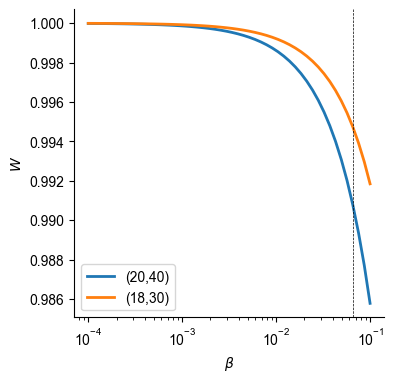

In [2]:
def expected_num_euploid_embryos(a, b, alpha=0.75, beta=0.066, c= -1.208, ba=1.08066, ba2=0.21276, mu = 35.95217, std = 4.89245):
    """The expected number of  a heterozygote carrier."""
    assert mu > 0
    assert std > 0
    assert b > a
    assert beta >= 0
    f = lambda x: (1.0-alpha) * (1. - expit(c + ba*((x- mu)/std) + ba2*(((x - mu)/std)**2) + beta))
    x = quad(f, a, b)
    return x

fig, ax = plt.subplots(1,1,figsize=(4,4))

betas = np.logspace(-4,-1, 50)
diffs = np.zeros(betas.size)
diffs2 = np.zeros(betas.size)
for i,b in tqdm(enumerate(betas)):
    diffs[i] = expected_num_euploid_embryos(20, 40, beta=b, alpha=0.75)[0] / expected_num_euploid_embryos(20, 40, beta=0.0, alpha=0.75)[0]
    diffs2[i] = expected_num_euploid_embryos(18, 30, beta=b, alpha=0.75)[0] / expected_num_euploid_embryos(18, 30, beta=0.0, alpha=0.75)[0] 

ax.plot(betas, diffs,label=r'(20,40)', lw=2)
ax.plot(betas, diffs2,label=r'(18,30)', lw=2)

ax.set_xscale('log')
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$W$')
ax.axvline(0.066, linestyle='--', lw=0.5, color='black')
ax.legend()
debox(ax)
# plt.savefig('effect_size_aneuploidy_risk.070825.png', dpi=300, bbox_inches='tight')

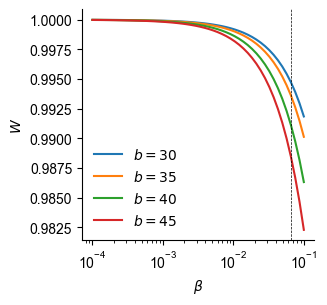

In [3]:
def est_selection_coefficient(beta=0.0, **kwargs):
    """Estimate the selection coefficient against the aneuploidy risk-increasing allele."""
    w =  expected_num_euploid_embryos(beta=beta, **kwargs)[0] / expected_num_euploid_embryos(beta=0.0, **kwargs)[0]
    return 1. - w

fig ,ax = plt.subplots(1,1,figsize=(3,3))
for b in [30, 35, 40, 45]:
    ws = np.array([1 - est_selection_coefficient(a=18, b=b, beta=bx) for bx in betas])
    ax.plot(betas, ws, label=f'$b={b}$')
ax.legend(frameon=False)
ax.set_xscale('log')
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$W$')
ax.axvline(0.066, linestyle='--', lw=0.5, color='black')
debox(ax)

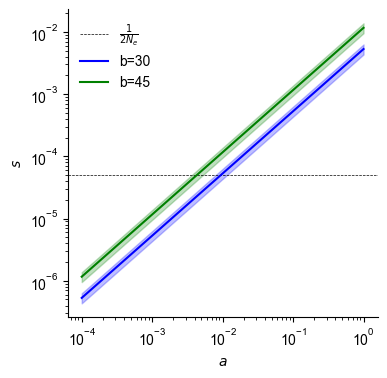

In [4]:
r2s = np.logspace(-4,0)
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.axhline(1/2e4, linestyle='--', color='black', label=r'$\frac{1}{2N_e}$', lw=0.5)
cs = ['blue', 'green', 'orange']
for i, b in enumerate([30, 45]):
    s_proxy = est_selection_coefficient(a=18, b=b, beta=0.066)
    s_lower = est_selection_coefficient(a=18, b=b, beta=0.066-1*0.01178)
    s_upper = est_selection_coefficient(a=18, b=b, beta=0.066+1*0.01178)
    ax.plot(r2s, r2s*s_proxy, color=cs[i], label=f'b={b}')
    ax.fill_between(r2s, r2s*s_lower, r2s*s_upper, color=cs[i], alpha=0.25)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$s$')
ax.legend(frameon=False)
debox(ax);

In [5]:
def obtain_focal_tree(ts, pos=45387213, focal_pos=45387213, window_size=2e6):
    """Function to obtain the focal tree from a given tree sequence."""
    idx = np.where(ts.sites_position + (focal_pos-2e6) == pos)[0]
    if idx.size > 0:
        site_x = ts.sites()[idx[0]]
        tree=ts.at(site_x.position, sample_lists=True)
        return tree, site_x
    else:
        raise ValueError(f'{pos} is not found as a site in the tree!')

def estimate_allele_freq(tree, node):
    """Estimate the allele frequency as a function of time."""
    times = np.array([tree.time(n) for n in tree.nodes(root=node,order='timeasc')][::-1])
    nodes = np.array([n for n in tree.nodes(root=node, order="timeasc")][::-1])
    n_carriers = np.arange(1, nodes.size+1)
    n_lineages = np.array([tree.num_lineages(t) for t in times])
    return times, n_carriers, n_lineages

In [6]:
times_agg = []
freqs_agg = []
nmut = []
for fp in tqdm(glob('../results/singer_trees/rs6006737/rs6006737.EUR.singer_*.trees')):
    ts = tskit.load(fp)
    tree, site = obtain_focal_tree(ts, pos=45413743)
    nmut.append(len(site.mutations))
    # print([(tree.num_samples(site.mutations[x].node), site.mutations[x]) for x in range(len(site.mutations))])
    times, n_carriers, n_lineages = estimate_allele_freq(tree, node=site.mutations[1].node)
    if times.size > 1:
        times_agg.append(times)
        if site.mutations[1].derived_state == '1':
            freqs_agg.append(n_carriers/n_lineages)
        else:
            freqs_agg.append(1.0 - n_carriers/n_lineages)
nmuts = np.array(nmut)
times_agg = np.hstack(times_agg)
freqs_agg = np.hstack(freqs_agg)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [00:06<00:00, 16.01it/s]


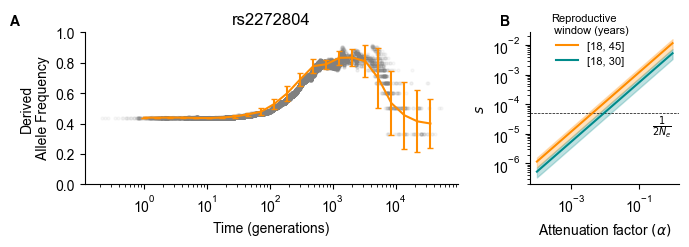

In [7]:
fig = plt.figure(layout="tight", figsize=(7,4.25))
gs = GridSpec(2, 2, width_ratios=[2.5, 1], height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[0])

# Plot the relationship here ... 
# ax1.axhline(1/2e4, linestyle='--', color='black', label=r'$\frac{1}{2N_e}$', lw=0.5)
ax1.axhline(1/2e4, linestyle='--', color='black', lw=0.5)
cs = ['#FF8C00', '#008B8B', 'orange']
for i, b in enumerate([45, 30]):
    s_proxy = est_selection_coefficient(a=18, b=b, beta=0.066)
    s_lower = est_selection_coefficient(a=18, b=b, beta=0.066-2*0.01178)
    s_upper = est_selection_coefficient(a=18, b=b, beta=0.066+2*0.01178)
    ax1.plot(r2s, r2s*s_proxy, color=cs[i], label=f'[18, {b}]')
    ax1.fill_between(r2s, r2s*s_lower, r2s*s_upper, color=cs[i], alpha=0.25)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'Attenuation factor $(\alpha)$')
ax1.set_ylabel(r'$s$')
legend = ax1.legend(frameon=False, title='Reproductive\n window (years)', loc='center', bbox_to_anchor=(0.4, 0.95), fontsize=8)
plt.setp(legend.get_title(),fontsize=8)
debox(ax1);
ax1.annotate(r'$\frac{1}{2N_e}$', (5e-1, 1/2e4), xytext=(5e-1, 1/2e4*0.95), ha='center', va='top', fontsize=10)

ax2.scatter(times_agg, freqs_agg, color='gray', alpha=0.05, s=5)
res_mean = binned_statistic(times_agg, freqs_agg, statistic=np.nanmean, bins=np.logspace(0, 6, 30))
res_err = binned_statistic(times_agg, freqs_agg, statistic=np.nanstd, bins=np.logspace(0, 6, 30))
ax2.errorbar(res_err.bin_edges[:-1], res_mean.statistic, yerr=2*res_err.statistic, capsize=2, color='#FF8C00')
# ax2.axhline(0.5, linestyle='--', lw=0.5, color='black')
ax2.set_xscale('log')
ax2.set_xlabel('Time (generations)')
ax2.set_ylabel('Derived\n Allele Frequency')
debox(ax2);
ax2.set_title(r'rs2272804', fontsize=12)
ax2.set_ylim(0,1)
label_multipanel([ax2, ax1], ['A', 'B'], xoff=-0.2, yoff=1.05, fontweight='bold')
# plt.savefig('figures/evolutionary_model.072425.png', bbox_inches='tight', dpi=300)
# plt.savefig('figures/evolutionary_model.072425.pdf', bbox_inches='tight', dpi=300)

In [8]:
1/(2e4*est_selection_coefficient(a=18, b=30, beta=0.066))

0.009431333054372668

In [9]:
# Lets build a definition of \gamma_a, \gamma_e

#1. Where we get numbers approximately 
# gamma_a  =  P(miscarriage | pregnancy, aneuploidy) * P(pregnancy | blastocyst) * P(blastocyst | aneuploid zygote)
# P(miscarriage | pregnancy, aneuploidy) = 0.86 from table 1 in capalbo et al 2022
# P(blastocyst | aneuploid zygote) ~= 1 - 0.36 from Figure 4B in McCoy et al 2023 (Genome Medicine) 
gamma_a = 0.86 * (1 - 0.36)


#2. Where we get numbers approximately for \gamma_e
# P(blastocyst | euploid zygote) ~= 1 - 0.16 from Figure 4B in McCoy et al 2023 (Genome Medicine)
# P(miscarriage | euploid blastocyst) ~= 12% from Table 1 in Capalbo et al 2021
gamma_e =  0.12 * (1 - 0.16)
gamma_a, gamma_e

(0.5504, 0.10079999999999999)

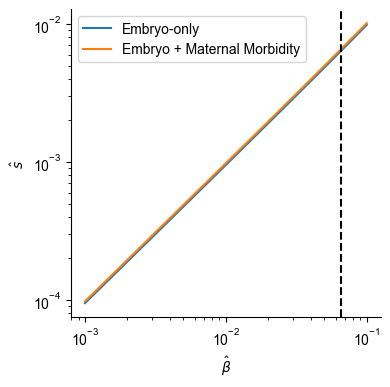

In [10]:
def fitness_mat_mortality_aneuploid_embryos(a=18, b=30, 
                                            p_aneu_mis = 0.5178, 
                                            p_eu_mis = 0.1008, 
                                            p_preg_risk = 5e-2, 
                                            beta=0.066, 
                                            c= -1.208, ba=1.08066, ba2=0.21276, mu = 35.95217, std = 4.89245):
    """The expected fitness effect of a heterozygote carrier considering maternal mortality effects
    
    Arguments: 
        - a: minimum reproductive age (years)
        - b: maximum reproductive age (years)
        - p_aneu_mis: probability of aneuploid zygote reaching clinical pregnancy stage
        - p_eu_mis: probability of euploid zygote reaching clinical pregnancy stage
        - p_preg_risk: probability of maternal mortality or loss of fertility from miscarriage 
        - beta: effect-size of GWAS allele 

    Returns:
        fitness: estimate of absolute fitness of the genotype
    
    """
    assert mu > 0
    assert std > 0
    assert b > a
    assert beta >= 0
    # Functions for expected probability of aneuploidy and not aneuploidy 
    f = lambda x: expit(c + ba*((x- mu)/std) + ba2*(((x - mu)/std)**2) + beta)
    # Expected number of euploid zygotes produced from a -> b
    x = quad(lambda x: 1. - f(x), a, b)[0]
    # Expected number of aneuploid zygotes produced from a -> b
    x2 = quad(f, a, b)[0]
    # Fitness is calculated as difference in expected number of euploid zygotes - expected risk of maternal mortality over same reproductive lifetime
    exp_n_euploid_zygotes = x
    exp_prob_mat_mortality = (p_aneu_mis * p_preg_risk * x2 + p_eu_mis * p_preg_risk * x) 
    fitness = exp_n_euploid_zygotes - exp_prob_mat_mortality
    return fitness

def est_selection_coefficient_mat_mortality(beta=0.0, **kwargs):
    """Estimate the selection coefficient against the aneuploidy risk-increasing allele."""
    w =  fitness_mat_mortality_aneuploid_embryos(beta=beta, **kwargs) / fitness_mat_mortality_aneuploid_embryos(beta=0.0, **kwargs)
    return 1. - w

betas = np.logspace(-3, -1, 100)
s_mat_mortality = np.array([est_selection_coefficient_mat_mortality(b=35, beta=b, p_preg_risk=0.05) for b in betas])
s_embryo_only = np.array([est_selection_coefficient(a=18, b=35, beta=b) for b in betas])

fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.loglog(betas, s_embryo_only, label=r'Embryo-only')
ax.loglog(betas, s_mat_mortality, label=r'Embryo + Maternal Morbidity')
ax.axvline(0.066, linestyle='--', color='black')
ax.set_xlabel(r'$\hat{\beta}$')
ax.set_ylabel(r'$\hat{s}$')
ax.legend()
debox(ax);

In [11]:
# Note: this shows that maternal mortality does have a slightly higher selection coefficient
diff_sel_18_30 = est_selection_coefficient(a=18, b=30, beta=0.066) - est_selection_coefficient_mat_mortality(a=18, b=30, beta=0.066, p_aneu_mis=gamma_a, p_eu_mis=gamma_e, p_preg_risk=5e-2)
diff_sel_18_45 = est_selection_coefficient(a=18, b=45, beta=0.066) - est_selection_coefficient_mat_mortality(a=18, b=45, beta=0.066, p_aneu_mis=gamma_a, p_eu_mis=gamma_e, p_preg_risk=5e-2)
print(diff_sel_18_30, diff_sel_18_45)

-0.0001594462329687074 -0.0004249953716110033


In [12]:
# NOTE: need a stronger attenuation in this case, but it is on O(10^{-4})
1/(2e4*est_selection_coefficient(a=18, b=30, beta=0.066)), 1/(2e4*est_selection_coefficient_mat_mortality(a=18, b=30, beta=0.066, p_preg_risk=0.05))

(0.009431333054372668, 0.009171856726569375)

Text(0, 0.5, '$\\Delta s_{proxy}$')

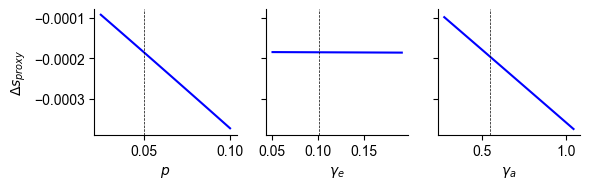

In [13]:
p_preg_risk = 0.05 + 0.05*np.linspace(-0.5,1,100)
gamma_e_risk = gamma_e + gamma_e * np.linspace(-0.5,0.9,100)
gamma_a_risk = gamma_a + gamma_a * np.linspace(-0.5,0.9,100)
fig, [ax0, ax1, ax2] = plt.subplots(1,3,figsize=(6,2), sharey=True, layout='tight')
ax0.plot(p_preg_risk, est_selection_coefficient(a=18, b=35, beta=0.066) - np.array([est_selection_coefficient_mat_mortality(a=18, b=35, beta=0.066, p_preg_risk=p) for p in p_preg_risk]), color='blue')
ax1.plot(gamma_e_risk, est_selection_coefficient(a=18, b=35, beta=0.066) - np.array([est_selection_coefficient_mat_mortality(a=18, b=35, beta=0.066, p_eu_mis=ge,  p_preg_risk=5e-2) for ge in gamma_e_risk]), color='blue')
ax2.plot(gamma_a_risk, est_selection_coefficient(a=18, b=35, beta=0.066) - np.array([est_selection_coefficient_mat_mortality(a=18, b=35, beta=0.066, p_aneu_mis=ga, p_preg_risk=5e-2) for ga in gamma_a_risk]), color='blue')
ax0.axvline(5e-2, lw=0.5, color='black', linestyle='--')
ax1.axvline(gamma_e, lw=0.5, color='black', linestyle='--')
ax2.axvline(gamma_a, lw=0.5, color='black', linestyle='--')

ax0.set_xlabel(r'$p$')
ax1.set_xlabel(r'$\gamma_e$')
ax2.set_xlabel(r'$\gamma_a$')
[debox(a) for a in [ax0, ax1, ax2]];
ax0.set_ylabel(r'$\Delta s_{proxy}$')
# plt.savefig('../figures/evo_model_mat_mortality.091525.png', bbox_inches='tight', dpi=300)
# plt.savefig('../figures/evo_model_mat_mortality.091525.pdf', bbox_inches='tight', dpi=300)

In [14]:
print(est_selection_coefficient(a=18, b=35, beta=0.066), est_selection_coefficient_mat_mortality(a=18, b=35, beta=0.066, p_aneu_mis=gamma_a, p_eu_mis=gamma_e, p_preg_risk=5e-2))
sel_diff_18_35 = est_selection_coefficient(a=18, b=35, beta=0.066) - est_selection_coefficient_mat_mortality(a=18, b=35, beta=0.066, p_aneu_mis=gamma_a, p_eu_mis=gamma_e, p_preg_risk=5e-2)
print(sel_diff_18_35)

0.006423543068046267 0.006620651700748881
-0.00019710863270261392
